# Notebook 02 — Download Forest Loss Labels (Hansen GFC 2022)

Downloads Hansen Global Forest Change v1.10 layers for the Gironde tile:
- `lossyear`: year of forest loss per pixel (value 22 = year 2022)
- `treecover2000`: canopy cover in year 2000 (used to confirm forest presence)

Creates a binary mask: pixels that were forest in 2000 (cover >= 10%) AND lost cover in 2022.

**Source**: Hansen/UMD/Google/USGS/NASA — publicly accessible GCS bucket  
**Environment**: local CPU  
**Runtime**: ~5 min

In [1]:
# === Cell 1: Imports & setup ===
import requests
import numpy as np
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.mask import mask as rio_mask
from rasterio.crs import CRS
from shapely.geometry import box, mapping
from pathlib import Path
from tqdm import tqdm

BASE       = Path('D:/GeoAI/forest-disturbance')
LABELS_DIR = BASE / 'data/raw/labels'
LABELS_DIR.mkdir(parents=True, exist_ok=True)

BBOX       = [-1.45, 44.42, -0.42, 45.05]   # WGS84 [minx, miny, maxx, maxy]
TARGET_CRS = 'EPSG:32630'                    # UTM zone 30N — same as Sentinel-2 tiles
TARGET_RES = 10                              # 10m — matches Sentinel-2 10m bands

# Hansen GFC tile covering Gironde: 50N_010W (40-50N, 0-10W)
HANSEN_BASE = 'https://storage.googleapis.com/earthenginepartners-hansen/GFC-2022-v1.10'
TILE        = '50N_010W'

print(f'Labels dir: {LABELS_DIR}')
print(f'Target CRS: {TARGET_CRS} @ {TARGET_RES}m')

Labels dir: D:\GeoAI\forest-disturbance\data\raw\labels
Target CRS: EPSG:32630 @ 10m


In [2]:
# === Cell 2: Download Hansen GFC layers ===
def download_file(url, out_path):
    if out_path.exists():
        print(f'Already exists: {out_path.name}')
        return
    resp  = requests.get(url, stream=True, timeout=120)
    resp.raise_for_status()
    total = int(resp.headers.get('content-length', 0))
    with open(out_path, 'wb') as f, tqdm(
            desc=out_path.name, total=total, unit='B', unit_scale=True) as bar:
        for chunk in resp.iter_content(1 << 20):
            f.write(chunk)
            bar.update(len(chunk))
    print(f'Done: {out_path.name} ({out_path.stat().st_size/1e6:.0f} MB)')

lossyear_raw  = LABELS_DIR / f'hansen_lossyear_{TILE}.tif'
treecover_raw = LABELS_DIR / f'hansen_treecover2000_{TILE}.tif'

download_file(f'{HANSEN_BASE}/Hansen_GFC-2022-v1.10_lossyear_{TILE}.tif', lossyear_raw)
download_file(f'{HANSEN_BASE}/Hansen_GFC-2022-v1.10_treecover2000_{TILE}.tif', treecover_raw)

hansen_lossyear_50N_010W.tif: 100%|██████████| 43.2M/43.2M [00:02<00:00, 15.0MB/s]


Done: hansen_lossyear_50N_010W.tif (43 MB)


hansen_treecover2000_50N_010W.tif: 100%|██████████| 219M/219M [00:07<00:00, 28.3MB/s] 

Done: hansen_treecover2000_50N_010W.tif (219 MB)


In [3]:
# === Cell 3: Clip to Gironde bbox ===
# Hansen tiles are in WGS84 — clip first, then reproject to UTM
gironde_geom = [mapping(box(*BBOX))]

def clip_raster(src_path, dst_path, geom):
    with rasterio.open(src_path) as src:
        out_image, out_transform = rio_mask(src, geom, crop=True)
        out_meta = src.meta.copy()
        out_meta.update({'height': out_image.shape[1], 'width': out_image.shape[2],
                         'transform': out_transform})
    with rasterio.open(dst_path, 'w', **out_meta) as dst:
        dst.write(out_image)
    print(f'Clipped: {dst_path.name}  shape={out_image.shape}')

lossyear_clipped  = LABELS_DIR / 'lossyear_gironde_wgs84.tif'
treecover_clipped = LABELS_DIR / 'treecover_gironde_wgs84.tif'

clip_raster(lossyear_raw,  lossyear_clipped,  gironde_geom)
clip_raster(treecover_raw, treecover_clipped, gironde_geom)

Clipped: lossyear_gironde_wgs84.tif  shape=(1, 2520, 4120)
Clipped: treecover_gironde_wgs84.tif  shape=(1, 2520, 4120)


In [4]:
# === Cell 4: Reproject to UTM 32630 at 10m ===
def reproject_raster(src_path, dst_path, dst_crs, res):
    with rasterio.open(src_path) as src:
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height,
            *src.bounds, resolution=res)
        kwargs = src.meta.copy()
        kwargs.update({'crs': dst_crs, 'transform': transform,
                       'width': width, 'height': height})
        with rasterio.open(dst_path, 'w', **kwargs) as dst:
            reproject(source=rasterio.band(src, 1),
                      destination=rasterio.band(dst, 1),
                      src_transform=src.transform,
                      src_crs=src.crs,
                      dst_transform=transform,
                      dst_crs=dst_crs,
                      resampling=Resampling.nearest)   # nearest for categorical data
    print(f'Reprojected: {dst_path.name}  size={width}x{height}')

lossyear_utm  = LABELS_DIR / 'lossyear_gironde_utm32630_10m.tif'
treecover_utm = LABELS_DIR / 'treecover_gironde_utm32630_10m.tif'

reproject_raster(lossyear_clipped,  lossyear_utm,  TARGET_CRS, TARGET_RES)
reproject_raster(treecover_clipped, treecover_utm, TARGET_CRS, TARGET_RES)

Reprojected: lossyear_gironde_utm32630_10m.tif  size=8334x7205
Reprojected: treecover_gironde_utm32630_10m.tif  size=8334x7205


In [5]:
# === Cell 5: Create binary forest loss mask ===
# Condition: treecover2000 >= 10% AND lossyear == 22 (year 2022)
with rasterio.open(lossyear_utm)  as src: lossyear  = src.read(1)
with rasterio.open(treecover_utm) as src:
    treecover = src.read(1)
    profile   = src.profile.copy()

forest_loss_2022 = ((lossyear == 22) & (treecover >= 10)).astype(np.uint8)

print(f'Total pixels  : {forest_loss_2022.size:,}')
print(f'Forest loss   : {forest_loss_2022.sum():,} ({forest_loss_2022.mean()*100:.2f}%)')
print(f'Area (ha)     : {forest_loss_2022.sum() * 10 * 10 / 10000:,.0f} ha')

out_mask = LABELS_DIR / 'forest_loss_2022_gironde.tif'
profile.update({'dtype': 'uint8', 'nodata': 255})
with rasterio.open(out_mask, 'w', **profile) as dst:
    dst.write(forest_loss_2022, 1)

print(f'\nSaved: {out_mask}')

Total pixels  : 60,046,470
Forest loss   : 706,166 (1.18%)
Area (ha)     : 7,062 ha

Saved: D:\GeoAI\forest-disturbance\data\raw\labels\forest_loss_2022_gironde.tif


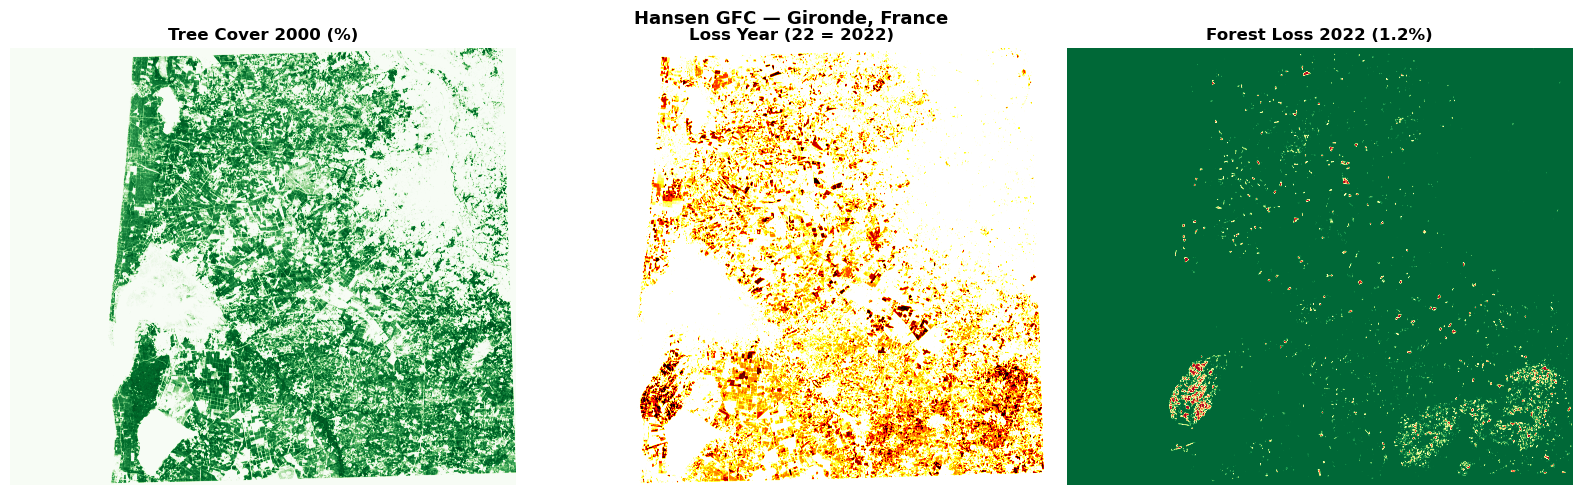

Saved: results/check_labels.png


In [6]:
# === Cell 6: Quick visual check ===
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(treecover, cmap='Greens', vmin=0, vmax=100)
axes[0].set_title('Tree Cover 2000 (%)', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(lossyear, cmap='hot_r', vmin=0, vmax=22)
axes[1].set_title('Loss Year (22 = 2022)', fontweight='bold')
axes[1].axis('off')

im = axes[2].imshow(forest_loss_2022, cmap='RdYlGn_r', vmin=0, vmax=1)
axes[2].set_title(f'Forest Loss 2022 ({forest_loss_2022.mean()*100:.1f}%)', fontweight='bold')
axes[2].axis('off')

plt.suptitle('Hansen GFC — Gironde, France', fontsize=13, fontweight='bold')
plt.tight_layout()
(BASE / 'results').mkdir(exist_ok=True)
plt.savefig(BASE / 'results/check_labels.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: results/check_labels.png')